In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import numpy as np

In [2]:
CONFIG = {
    "dataset_path": "TrashBox_train_set",
    "num_classes": 7,
    "image_size": 224,
    "batch_size": 16,
    "num_epochs": 10,
    "learning_rate": 0.001,
    "val_split": 0.15,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "seed": 42
}

In [3]:
train_transforms = transforms.Compose([
    transforms.Resize((CONFIG["image_size"], CONFIG["image_size"])),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
 
val_transforms = transforms.Compose([
    transforms.Resize((CONFIG["image_size"], CONFIG["image_size"])),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],std=[0.229, 0.224, 0.225]),
])

In [4]:
full_dataset = datasets.ImageFolder(root=CONFIG["dataset_path"], transform=train_transforms)
 
val_size   = int(len(full_dataset) * CONFIG["val_split"])
train_size = len(full_dataset) - val_size
train_set, val_set = random_split(full_dataset, [train_size, val_size])
 

In [5]:
# Applying val transforms to the validation subset
val_set.dataset = datasets.ImageFolder(root=CONFIG["dataset_path"], transform=val_transforms)
 
train_loader = DataLoader(train_set, batch_size=CONFIG["batch_size"], shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_set,   batch_size=CONFIG["batch_size"], shuffle=False, num_workers=2, pin_memory=True)

In [ ]:
#The model
class CNN(nn.Module):
    def __init__(self, config):
        super().__init__()

        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
        )

        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
        )

        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
        )

        self.block4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((4, 4)),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, config["num_classes"]),
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.classifier(x)
        return x


model = CNN(CONFIG).to(CONFIG["device"])
print(model)

CNN(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block4): Sequential(
    (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1

In [7]:
#Checking whether the model works
x = torch.randn(1, 3, CONFIG["image_size"], CONFIG["image_size"]).to(CONFIG["device"])
y = model(x)

print(y.shape)

torch.Size([1, 7])


In [8]:
#the loss, optimizer and scheduler
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=CONFIG["learning_rate"], weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", patience=5, factor=0.5)

In [9]:
from tqdm import tqdm

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in tqdm(loader, desc="Training", leave=False):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(dim=1) == labels).sum().item()
        total += images.size(0)

    return total_loss / total, correct / total

In [10]:
#evaluation loop
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            correct += (outputs.argmax(dim=1) == labels).sum().item()
            total += images.size(0)

    return total_loss / total, correct / total


In [11]:
#training loop with early stopping
best_val_loss = np.inf
patience_counter = 0
PATIENCE = 8

train_losses = []
val_losses = []
train_accs = []
val_accs = []
 
for epoch in range(1, CONFIG["num_epochs"] + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, CONFIG["device"])
    val_loss,   val_acc   = evaluate(model, val_loader, criterion, CONFIG["device"])
    scheduler.step(val_loss)
    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []
 
    print(f"Epoch {epoch:02d}/{CONFIG["num_epochs"]} | "
          f"Train loss: {train_loss:.4f}  acc: {train_acc:.4f} | "
          f"Val loss: {val_loss:.4f}  acc: {val_acc:.4f}")
 
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), "best_cnn.pth")
        print("  → Saved best model")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early stopping at epoch {epoch}")
            break
 
print("Training complete. Best val loss:", round(best_val_loss, 4))
 

Training:   0%|          | 0/759 [00:00<?, ?it/s]c:\Users\LIONESS\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 01/10 | Train loss: 1.8526  acc: 0.2658 | Val loss: 1.6709  acc: 0.3671
  → Saved best model


Epoch 02/10 | Train loss: 1.7411  acc: 0.3227 | Val loss: 1.6388  acc: 0.3769
  → Saved best model


Epoch 03/10 | Train loss: 1.6982  acc: 0.3417 | Val loss: 1.5773  acc: 0.4078
  → Saved best model


Epoch 04/10 | Train loss: 1.6603  acc: 0.3700 | Val loss: 1.5316  acc: 0.4367
  → Saved best model


...

Epoch 06/10 | Train loss: 1.5875  acc: 0.4088 | Val loss: 1.4427  acc: 0.4633
  → Saved best model


Epoch 07/10 | Train loss: 1.5434  acc: 0.4287 | Val loss: 1.4026  acc: 0.4872
  → Saved best model


Epoch 08/10 | Train loss: 1.5183  acc: 0.4449 | Val loss: 1.4045  acc: 0.4783


Epoch 09/10 | Train loss: 1.4817  acc: 0.4645 | Val loss: 1.3383  acc: 0.5086
  → Saved best model


Epoch 10/10 | Train loss: 1.4485  acc: 0.4795 | Val loss: 1.2923  acc: 0.5367
  → Saved best model
Training complete. Best val loss: 1.2923


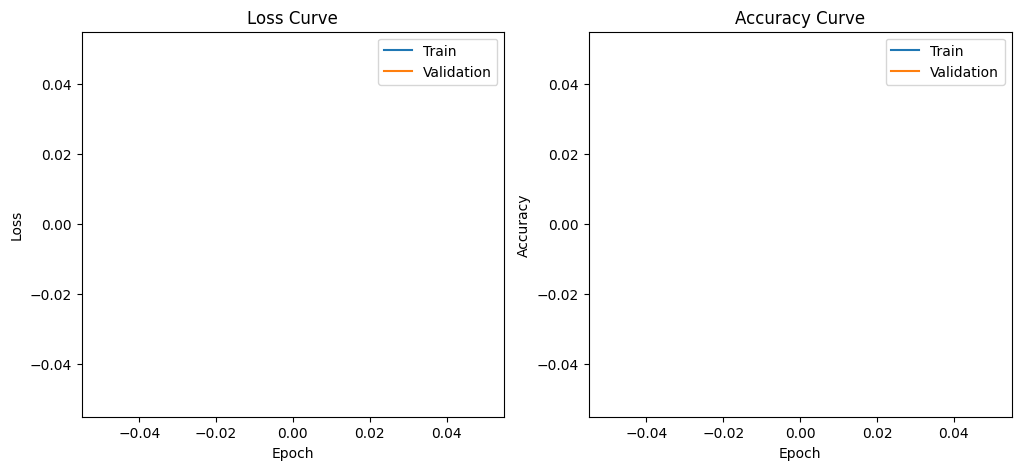

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(train_losses, label="Train")
plt.plot(val_losses, label="Validation")
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(train_accs, label="Train")
plt.plot(val_accs, label="Validation")
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

In [15]:
#Loading the best model and doing the final evaluation
model.load_state_dict(torch.load("best_cnn.pth"))
test_loss, test_acc = evaluate(model, val_loader, criterion, CONFIG["device"])
print(f"Final val accuracy: {test_acc:.4f}")

Final val accuracy: 0.5367
